# Usage | 4. Data export and visualization
This notebook explains how a bike network grown by GrowBikeNet can be exported and visualized.

**Parameters and settings covered**: `export_data`, `city_query`, `city_id`, `export_plots`, `settings.viz`

We start every Usage notebook with the standard way of importing GrowBikeNet:

In [1]:
import growbikenet as gbn

## City query is not the city name

So far the first parameter provided to GrowBikeNet was a city's name. However, technically this parameter is not necessarily the name, but a query string used by OpenStreetMap's search engine [Nominatim](https://nominatim.openstreetmap.org/) to retrieve data about the city. Often this is identical to the city name, but sometimes it is not. For example, running `edges_ordered = gbn.growbikenet("Athens")` retrieves data for Athens, Georgia in the US. To retrieve data for Athens, Greece, the city query needs to be "Municipality of Athens": `edges_ordered = gbn.growbikenet("Municipality of Athens")`. This difference in name and query has consequences for finding the right city, but also for exporting the data.

## Providing a city id

Running GrowBikeNet with the parameter `export_data=True` will export the resulting ordered edges to a `gpkg` file. By default `export_data` is already set to `True`. Here we don't even care anymore about the output `edges_ordered`, since the data is exported anyway.

In [2]:
gbn.growbikenet("Municipality of Athens", export_data=True);

RUNNING GROWBIKENET FOR CITY: Municipality of Athens
betweenness | auto | from scratch
----------------------------------------------╮


Creating seed points   :   0%|                | 0/3 [00:00<?, ?step/s]

Triangulation          :   0%|                | 0/1 [00:00<?, ?step/s]

Routing                :   0%|                | 0/3 [00:00<?, ?step/s]

Computing edge metrics :   0%|                | 0/2 [00:00<?, ?step/s]

Rerouting              :   0%|                | 0/28 [00:00<?, ?edge/s]

Removing edge overlaps :   0%|                | 0/28 [00:00<?, ?edge/s]

Exporting data         :   0%|                | 0/1 [00:00<?, ?file/s]

----------------------------------------------╯
Data exported to ./results/
----------------------------------------------
FINISHED IN 0:00:05


The file is called `municipalityofathens-growbikenet-betweenness-from_scratch-grid_square.gpkg`, by default in the `./results` folder. The file name is separated by hyphens into parts. The first part `municipalityofathens` is the city id, which is an automatically "slugified" version of the `city_query` parameter `"Municipality of Athens"`. Slugification is important to turn city names with special characters such as `"L'Hospitalet De Llobregat"` into a string that can be part of a file name, in this case `"lhospitaletdellobregat`. The other filename parts show that the file came from `growbikenet`, and report the most important parameters: The `ordering` of `betweenness`, that the network was grown from scratch `from_scratch`, and the `seed_point_type` being `grid_square`.

To provide a name for the file that corresponds better with the city name, a `city_id` can be provided:

In [3]:
gbn.growbikenet(
    "Municipality of Athens", 
    export_data=True,
    city_id="athens",
);

RUNNING GROWBIKENET FOR CITY: Municipality of Athens
betweenness | auto | from scratch
----------------------------------------------╮


Creating seed points   :   0%|                | 0/3 [00:00<?, ?step/s]

Triangulation          :   0%|                | 0/1 [00:00<?, ?step/s]

Routing                :   0%|                | 0/3 [00:00<?, ?step/s]

Computing edge metrics :   0%|                | 0/2 [00:00<?, ?step/s]

Rerouting              :   0%|                | 0/28 [00:00<?, ?edge/s]

Removing edge overlaps :   0%|                | 0/28 [00:00<?, ?edge/s]

Exporting data         :   0%|                | 0/1 [00:00<?, ?file/s]

----------------------------------------------╯
Data exported to ./results/
----------------------------------------------
FINISHED IN 0:00:06


This creates the better filename `athens-growbikenet-betweenness-from_scratch-grid_square.gpkg`.

## Generating plots

Setting `export_plots=True`, GrowBikeNet allows exporting the growing network as plots, one plot per growth step:

In [4]:
gbn.growbikenet("Municipality of Athens", export_plots=True);

RUNNING GROWBIKENET FOR CITY: Municipality of Athens
betweenness | auto | from scratch
----------------------------------------------╮


Creating seed points   :   0%|                | 0/3 [00:00<?, ?step/s]

Triangulation          :   0%|                | 0/1 [00:00<?, ?step/s]

Routing                :   0%|                | 0/3 [00:00<?, ?step/s]

Computing edge metrics :   0%|                | 0/2 [00:00<?, ?step/s]

Rerouting              :   0%|                | 0/28 [00:00<?, ?edge/s]

Removing edge overlaps :   0%|                | 0/28 [00:00<?, ?edge/s]

Exporting data         :   0%|                | 0/1 [00:00<?, ?file/s]

Generating plots       : 100%|████████████████| 27/27 [00:02<00:00, 12.83plot/s]

----------------------------------------------╯
Data exported to ./results/
Plots exported to ./results/plots/
----------------------------------------------
FINISHED IN 0:00:08


The results are saved by default in the folder `./results/plots/ordering_[ordering]`, where `[ordering]` is the ordering parameter, here `betweenness`.

By default the plots look like this - showing 3 growth steps:

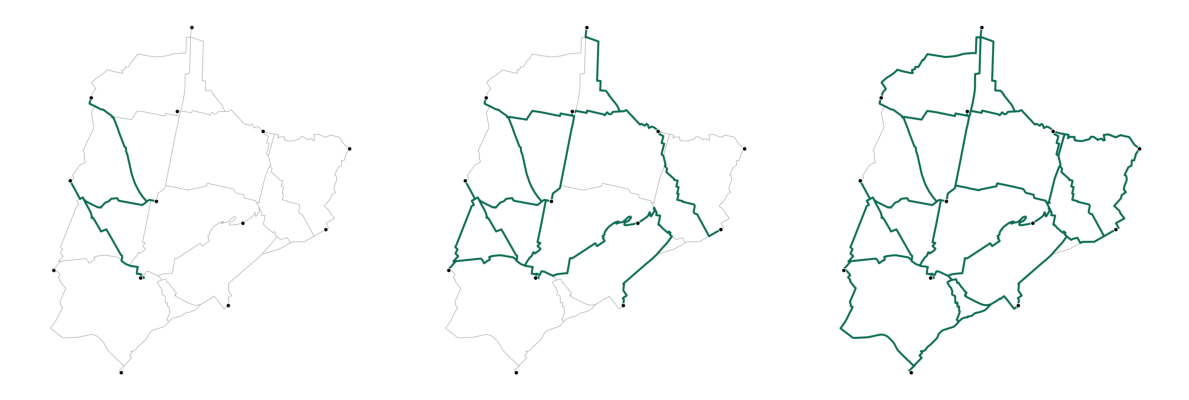

In [6]:
import matplotlib.image as mpimg
import matplotlib.pyplot as plt

def show_3_plots():
    fig, ax = plt.subplots(1,3,figsize=(12,48))
        
    ax[0].imshow(mpimg.imread('./results/plots/ordering_betweenness/0003.png'))
    ax[0].axis('off')
    ax[1].imshow(mpimg.imread('./results/plots/ordering_betweenness/0013.png'))
    ax[1].axis('off')
    ax[2].imshow(mpimg.imread('./results/plots/ordering_betweenness/0024.png'))
    ax[2].axis('off')
    fig.tight_layout()

show_3_plots()

The appearance can be modified in many ways using the `settings.viz`. Its default values are:

In [7]:
gbn.settings.viz

{'bike_to_grow': {'color': '#999999', 'line_width': 0.75},
 'bike_grown': {'color': '#096a51', 'line_width': 3},
 'bike_existing': {'color': '#9999cc', 'line_width': 2},
 'seed_point': {'color': '#000000', 'edgecolor': '#FFFFFF', 'markersize': 40},
 'dpi': 150,
 'crs': 'auto'}

For example:

In [8]:
gbn.settings.viz["bike_to_grow"]["color"] = "#000000"
gbn.settings.viz["bike_to_grow"]["line_width"] = 1
gbn.settings.viz["bike_grown"]["color"] = "#FF0000"
gbn.settings.viz["bike_grown"]["line_width"] = 5
gbn.settings.viz["seed_point"]["markersize"] = 0

In [9]:
gbn.growbikenet("Municipality of Athens", export_plots=True);

RUNNING GROWBIKENET FOR CITY: Municipality of Athens
betweenness | auto | from scratch
----------------------------------------------╮


Creating seed points   :   0%|                | 0/3 [00:00<?, ?step/s]

Triangulation          :   0%|                | 0/1 [00:00<?, ?step/s]

Routing                :   0%|                | 0/3 [00:00<?, ?step/s]

Computing edge metrics :   0%|                | 0/2 [00:00<?, ?step/s]

Rerouting              :   0%|                | 0/28 [00:00<?, ?edge/s]

Removing edge overlaps :   0%|                | 0/28 [00:00<?, ?edge/s]

Exporting data         :   0%|                | 0/1 [00:00<?, ?file/s]

Generating plots       : 100%|████████████████| 27/27 [00:02<00:00, 12.15plot/s]

----------------------------------------------╯
Data exported to ./results/
Plots exported to ./results/plots/
----------------------------------------------
FINISHED IN 0:00:08


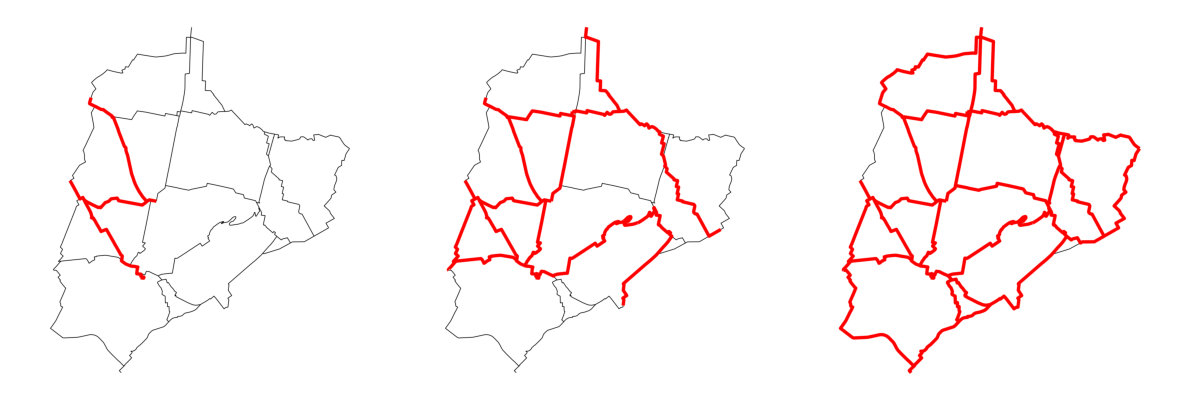

In [10]:
show_3_plots()

## Generating videos

The generated plots can be used as frames for a video. Due to packaging issues with Windows, video generation is not part of the official `growbikenet` conda package, but we provide a script which you can run to generate a video from the plots: [https://github.com/BikeNetKit/GrowBikeNet/blob/main/examples/generate_video.py](https://github.com/BikeNetKit/GrowBikeNet/blob/main/examples/generate_video.py)

It requires the extra dependency of `cv2` (OpenCV) which can be installed on most operating systems via: `pip install opencv-python`

To use it, first set the parameters inside the script (`ordering`, `folder`, `fps`), then run it via `python generate_video.py`.